# Attention Is All You Need

The previous two notebooks showed an RNN and then an RNN augmented with an attention mechanism. This notebook asks: what if we *only* use attention—no RNN at all?

The title is a nod to the 2017 paper "Attention Is All You Need" by Vaswani et al., which introduced the Transformer. We won't build a full Transformer—we'll build the simplest possible attention-only language model, stripping away everything except the core idea.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using {device}")

# ── data ──────────────────────────────────────────────────────────────────────
files = sorted(Path("data/oz").glob("*.txt"))
raw_lines = []
for path in files:
    raw_lines.extend(path.read_text(encoding="utf-8").splitlines())

lines = [line.strip() for line in raw_lines if line.strip()]
max_len = 80
lines = [line[: max_len - 1] + "\n" for line in lines]

chars = sorted(set("".join(lines)))
pad_token = "<PAD>"
vocab = [pad_token] + chars
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for ch, i in stoi.items()}
pad_id = stoi[pad_token]
vocab_size = len(vocab)

def encode(text):
    return [stoi[ch] for ch in text]

def decode(ids):
    return "".join(itos[i] for i in ids if i != pad_id)

encoded = torch.full((len(lines), max_len), pad_id, dtype=torch.long)
for i, line in enumerate(lines):
    ids = torch.tensor(encode(line), dtype=torch.long)
    encoded[i, : len(ids)] = ids

x_data = encoded[:, :-1]   # input: all but last char
y_data = encoded[:, 1:]    # target: all but first char (shifted by 1)
train_ds = TensorDataset(x_data, y_data)

print(f"{len(lines):,} lines, vocab size {vocab_size}, sequence length {max_len - 1}")

using cpu


56,131 lines, vocab size 77, sequence length 79


## No RNN — just attention

In the RNN+attention notebook, the RNN reads characters one at a time left-to-right, building a hidden state. Attention then lets each output position look directly at any earlier position, solving the vanishing-gradient problem.

But if attention already does that, why keep the RNN?

This notebook removes it entirely. Each character position gets two learned vectors:

1. A **token embedding** — a vector encoding which character it is  
2. A **position embedding** — a vector encoding where in the sequence it sits

One round of causal self-attention mixes them. That's the whole model.

## Step 1: Embeddings

Instead of 77-dimensional one-hot vectors (one 1, rest 0), we use *learned embeddings*: compact vectors of `d_model` real numbers for each character and each position.

```python
tok_emb = nn.Embedding(vocab_size, d_model)  # one row per character
pos_emb = nn.Embedding(max_len,   d_model)   # one row per position
```

The input at position $t$ is just:

$$x_t = \texttt{tok\_emb}[\text{id}_t] + \texttt{pos\_emb}[t]$$

This is the "cheesy" positional encoding: learned, one line of code, and exactly analogous to character embeddings. No sinusoids, no math. The model learns what each position means from data.

In [2]:
d_model = 64

seq = "Dorothy"
ids = torch.tensor(encode(seq), dtype=torch.long)
T = len(ids)
pos = torch.arange(T)

_tok_emb = nn.Embedding(vocab_size, d_model)
_pos_emb = nn.Embedding(max_len - 1, d_model)

x = _tok_emb(ids) + _pos_emb(pos)   # (T, d_model)

print(f"Input ids:  {ids.tolist()}   ← one index per character")
print(f"Positions:  {pos.tolist()}")
print(f"x shape:    {tuple(x.shape)}   ← (T={T}, d_model={d_model})")
print(f"x[0,:6]:    {x[0, :6].detach().numpy().round(3)}   ← embedding for 'D' at position 0")

Input ids:  [28, 65, 68, 65, 70, 58, 75]   ← one index per character
Positions:  [0, 1, 2, 3, 4, 5, 6]
x shape:    (7, 64)   ← (T=7, d_model=64)
x[0,:6]:    [-1.27  -0.873  1.635  3.279  0.689  2.023]   ← embedding for 'D' at position 0


## Step 2: Queries, Keys, and Values

Each position projects its embedding into three roles:

- **Query** ($Q$): "what information am I looking for?"  
- **Key** ($K$): "what information do I offer to others?"  
- **Value** ($V$): "what content do I carry?"

$$Q = x W_Q, \quad K = x W_K, \quad V = x W_V$$

The **attention score** from position $i$ to position $j$ measures how well query $i$ matches key $j$:

$$\text{score}_{ij} = \frac{q_i \cdot k_j}{\sqrt{d}}$$

Dividing by $\sqrt{d}$ prevents the dot products from exploding as $d$ grows.

To prevent "cheating" (attending to characters not yet seen), we apply a **causal mask**: set future scores to $-\infty$ so softmax gives them zero weight:

$$\text{attn}_{ij} = \text{softmax}_j(\text{score}_{ij}), \qquad \text{score}_{ij} = -\infty \text{ if } j > i$$

Attention matrix rows=query, cols=key (random untrained weights):
Characters: ['D', 'o', 'r', 'o', 't', 'h', 'y']

Row sums (should all be 1.0): [1. 1. 1. 1. 1. 1. 1.]
Upper-triangle max (should be 0.0): 0.0


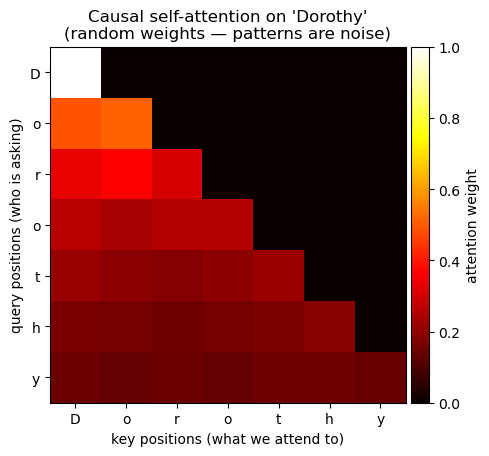

In [3]:
_W_q = torch.randn(d_model, d_model) * 0.02
_W_k = torch.randn(d_model, d_model) * 0.02
_W_v = torch.randn(d_model, d_model) * 0.02

q = x @ _W_q   # (T, d_model)
k = x @ _W_k
v = x @ _W_v

scores = q @ k.T / math.sqrt(d_model)   # (T, T)

causal_mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
scores_masked = scores.masked_fill(causal_mask, float("-inf"))

attn = torch.softmax(scores_masked, dim=-1)   # (T, T)

print("Attention matrix rows=query, cols=key (random untrained weights):")
print("Characters:", list(seq))
print()
print("Row sums (should all be 1.0):", attn.detach().sum(dim=-1).numpy().round(3))
print("Upper-triangle max (should be 0.0):", float(torch.triu(attn, diagonal=1).max().detach()))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(attn.detach(), cmap="hot", vmin=0, vmax=1, interpolation="nearest")
ax.set_xticks(range(T), list(seq))
ax.set_yticks(range(T), list(seq))
ax.set_xlabel("key positions (what we attend to)")
ax.set_ylabel("query positions (who is asking)")
ax.set_title("Causal self-attention on 'Dorothy'\n(random weights — patterns are noise)")
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, label="attention weight")
plt.tight_layout()
plt.show()

## Step 3: Context, residual, and output

The **context** at each position is the attention-weighted average of values:

$$c_t = \sum_{j \le t} \text{attn}_{tj} \cdot v_j$$

We add it back to the original embedding (**residual connection**) so the model can blend both local (embedding) and relational (attention) information:

$$\hat{x}_t = x_t + c_t$$

A final linear layer maps each `d_model`-dimensional vector to `vocab_size` logits — one score per possible next character.

In [4]:
context = attn @ v          # (T, d_model)
combined = x + context      # residual

_out = nn.Linear(d_model, vocab_size, bias=False)
logits = _out(combined)     # (T, vocab_size)

print(f"context shape: {tuple(context.shape)}   ← attention-weighted values")
print(f"logits  shape: {tuple(logits.shape)}   ← one score per vocab item, per position")

probs_last = torch.softmax(logits[-1].detach(), dim=-1)
top5 = probs_last.topk(5)
print("\nTop-5 predicted next chars after 'Dorothy' (random weights — meaningless):")
for prob, idx in zip(top5.values, top5.indices):
    print(f"  {itos[idx.item()]!r:6s}  {prob.item():.4f}")

context shape: (7, 64)   ← attention-weighted values
logits  shape: (7, 77)   ← one score per vocab item, per position

Top-5 predicted next chars after 'Dorothy' (random weights — meaningless):
  't'     0.0866
  'm'     0.0672
  'P'     0.0521
  'F'     0.0352
  'z'     0.0338


## The full model

All four steps in one class. The forward pass is 10 lines of arithmetic.

In [5]:
class MinimalAttentionLM(nn.Module):
    """Character-level language model: embeddings + single-head causal self-attention."""

    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()
        self.d_model = d_model
        scale = 0.02
        self.tok_emb = nn.Embedding(vocab_size, d_model)    # learned char vectors
        self.pos_emb = nn.Embedding(max_len, d_model)        # learned position vectors
        self.W_q = nn.Parameter(torch.randn(d_model, d_model) * scale)
        self.W_k = nn.Parameter(torch.randn(d_model, d_model) * scale)
        self.W_v = nn.Parameter(torch.randn(d_model, d_model) * scale)
        self.out  = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, x_ids, return_attn=False):
        B, T = x_ids.shape
        pos = torch.arange(T, device=x_ids.device)

        # 1. combine token and position embeddings
        x = self.tok_emb(x_ids) + self.pos_emb(pos)              # (B, T, d_model)

        # 2. project to queries, keys, values
        q = x @ self.W_q                                           # (B, T, d_model)
        k = x @ self.W_k
        v = x @ self.W_v

        # 3. scaled dot-product attention with causal mask
        scores = q @ k.transpose(1, 2) / math.sqrt(self.d_model)  # (B, T, T)
        mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))
        attn = torch.softmax(scores, dim=-1)                       # (B, T, T)

        # 4. weighted sum, residual, project to vocab
        context = attn @ v                                         # (B, T, d_model)
        logits  = self.out(x + context)                           # (B, T, vocab_size)

        if return_attn:
            return logits, attn
        return logits


model = MinimalAttentionLM(vocab_size=vocab_size, d_model=d_model, max_len=max_len - 1).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")

Parameters: 27,200


## Training

Same setup as the previous notebooks: cross-entropy loss over non-padding tokens, Adam, gradient clipping.

In [6]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

batch_size = 256
epochs = 10
loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
loss_history = []

for epoch in range(epochs):
    total_loss = 0.0
    total_tokens = 0
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        token_count = (yb != pad_id).sum().item()
        total_loss  += loss.item() * token_count
        total_tokens += token_count
        loss_history.append(loss.item())
    mean_nll = total_loss / total_tokens
    print(f"epoch {epoch + 1:2d}: mean token NLL = {mean_nll:.4f}")

epoch  1: mean token NLL = 2.5520


epoch  2: mean token NLL = 2.1775


epoch  3: mean token NLL = 2.1133


epoch  4: mean token NLL = 2.0875


epoch  5: mean token NLL = 2.0723


epoch  6: mean token NLL = 2.0632


epoch  7: mean token NLL = 2.0565


epoch  8: mean token NLL = 2.0520


epoch  9: mean token NLL = 2.0483


epoch 10: mean token NLL = 2.0455


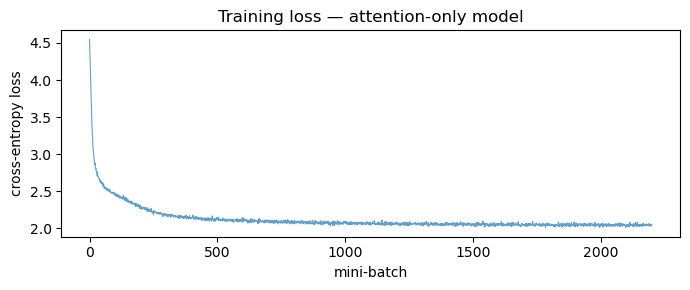

In [7]:
plt.figure(figsize=(7, 3))
plt.plot(loss_history, lw=0.8, alpha=0.7)
plt.xlabel("mini-batch")
plt.ylabel("cross-entropy loss")
plt.title("Training loss — attention-only model")
plt.tight_layout()
plt.show()

## Text generation

At each step, we feed the entire context into the model and sample from the last position's predicted distribution. No hidden state to track — the full sequence is the context.

In [8]:
@torch.no_grad()
def generate_line(model, prompt="The ", max_new_chars=60, temperature=0.8):
    model.eval()
    text = prompt if prompt else "T"
    ids = torch.tensor(
        [stoi[ch] for ch in text], dtype=torch.long, device=device
    ).unsqueeze(0)
    for _ in range(max_new_chars):
        logits, _ = model(ids, return_attn=True)
        next_logits = logits[0, -1] / temperature
        probs = torch.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).item()
        next_char = itos[next_id]
        if next_char == "\n":
            break
        text += next_char
        ids = torch.cat(
            [ids, torch.tensor([[next_id]], dtype=torch.long, device=device)], dim=1
        )
    return text

for prompt in ["The ", '"I ', "Dorothy ", "Oz ", "The Scarecrow "]:
    print(f"{prompt!r:20s} → {generate_line(model, prompt)}")

'The '               → The aser an war love Wizar spis the the, bot graw loos bealdem t
'"I '                → "I doolk lint wis ald, nowh whe be offever wey erly acre, he er
'Dorothy '           → Dorothy un there the serse the mouns we mapplick."
'Oz '                → Oz Yever he Sock Girs. Youne wou paithass depon.  Heing hag,"
'The Scarecrow '     → The Scarecrow bow the lige cout dere of or do er the pupon, andy win.


## Attention heatmaps

Each cell $(i, j)$ shows how much position $i$ (the *query*) attends to position $j$ (the *key*). The causal mask zeroes out the upper triangle — no position can peek at the future.

After training, look for:
- **Diagonal attention** — the immediately preceding character is often the strongest signal
- **Attention to spaces and capitals** — word boundaries help predict the next character
- **Long-range dependencies** — e.g., open quotes shaping predictions further along the line

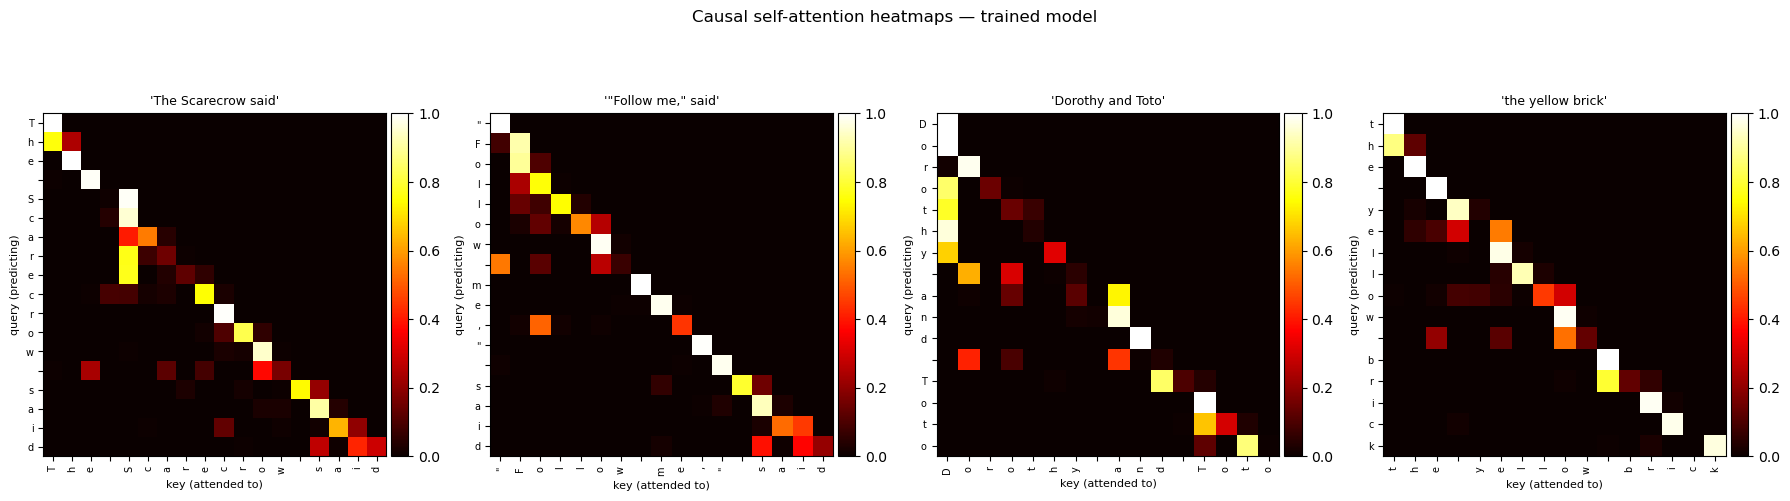

In [9]:
def attn_heatmap(model, text, ax, title=None):
    model.eval()
    ids = torch.tensor(encode(text), dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        _, attn_weights = model(ids, return_attn=True)
    attn_map = attn_weights[0].cpu()
    labels = list(text)
    T = len(labels)

    im = ax.imshow(attn_map, cmap="hot", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks(range(T), labels, rotation=90, fontsize=7)
    ax.set_yticks(range(T), labels, fontsize=7)
    ax.set_xlabel("key (attended to)", fontsize=8)
    ax.set_ylabel("query (predicting)", fontsize=8)
    if title:
        ax.set_title(title, fontsize=9)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    ax.get_figure().colorbar(im, cax=cax)
    return attn_map

prompts = [
    "The Scarecrow said",
    '"Follow me," said',
    "Dorothy and Toto",
    "the yellow brick",
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, text in zip(axes, prompts):
    attn_heatmap(model, text, ax=ax, title=repr(text))
fig.suptitle("Causal self-attention heatmaps — trained model", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

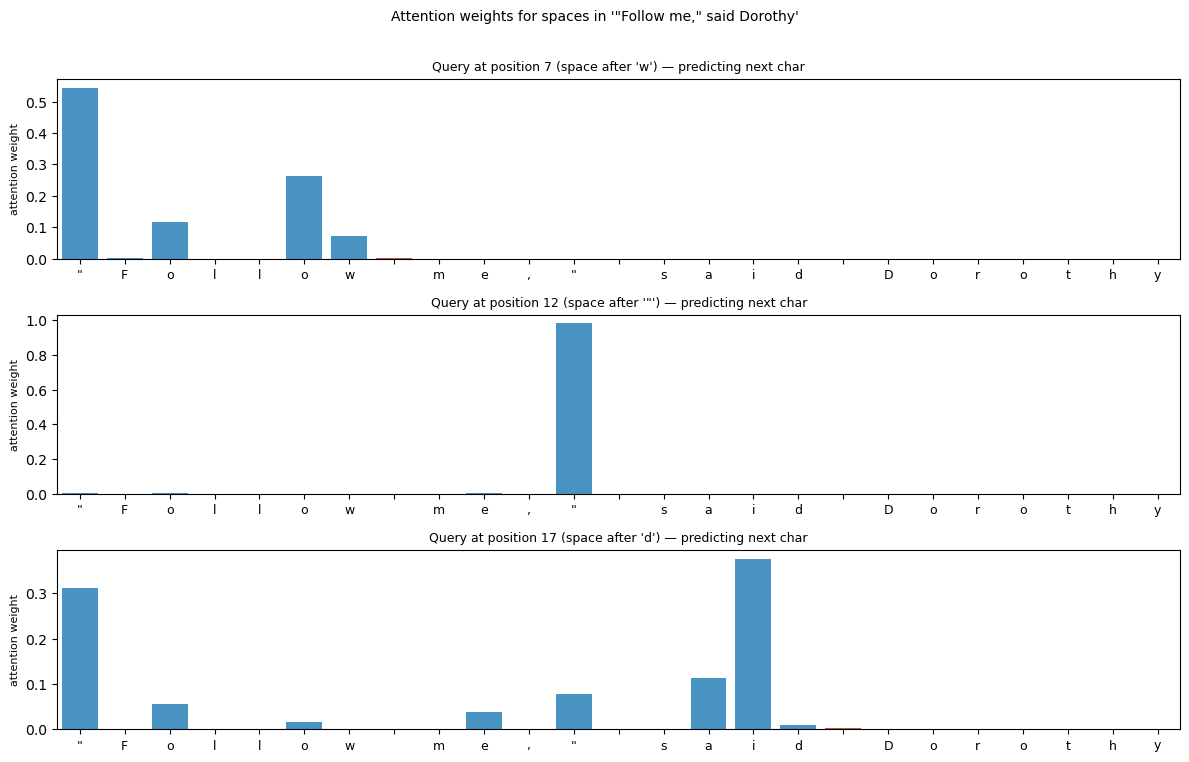

In [10]:
# Zoom in: attention weights at a single query position
text = '"Follow me," said Dorothy'
ids = torch.tensor(encode(text), dtype=torch.long, device=device).unsqueeze(0)
with torch.no_grad():
    _, attn_weights = model(ids, return_attn=True)
attn_map = attn_weights[0].cpu()

# Show what each space character attends to
space_positions = [i for i, ch in enumerate(text) if ch == " "]

fig, axes = plt.subplots(len(space_positions), 1, figsize=(12, 2.5 * len(space_positions)))
if len(space_positions) == 1:
    axes = [axes]

for ax, qpos in zip(axes, space_positions):
    weights = attn_map[qpos].numpy()
    colors = ["#c0392b" if i == qpos else "#2980b9" for i in range(len(text))]
    ax.bar(range(len(text)), weights, color=colors, alpha=0.85)
    ax.set_xticks(range(len(text)), list(text), fontsize=9)
    ax.set_ylabel("attention weight", fontsize=8)
    context_str = repr(text[:qpos + 1])
    ax.set_title(f"Query at position {qpos} (space after {text[qpos-1]!r}) — predicting next char", fontsize=9)
    ax.set_xlim(-0.5, len(text) - 0.5)

plt.suptitle(f"Attention weights for spaces in {text!r}", fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

## What this model is missing (vs. a full Transformer)

This model is dramatically simpler than the architecture in "Attention Is All You Need." Here's what we omitted and why it matters in larger models:

| Missing piece | What it adds | Why we skipped it |
|---|---|---|
| **Multi-head attention** | Multiple attention patterns simultaneously | Requires splitting and concatenating heads; one head already shows the idea |
| **Feed-forward network** | Position-wise nonlinear transformation after attention | Greatly increases capacity, but obscures the pure attention story |
| **Layer normalization** | Stabilizes training by normalizing activations | Critical for deep/wide models; not needed here |
| **Multiple layers** | Hierarchical, compositional feature learning | Each layer dramatically increases complexity |
| **Dropout** | Regularization to prevent overfitting | Training corpus is large relative to model size |

Even without any of these, the model learns to generate plausible Oz-like text purely through attention. The heatmaps show the learned patterns: spaces, capitals, and punctuation receive consistent attention across positions — exactly what you'd expect for character-level prediction.

A full Transformer scales these ideas — more heads, more layers, larger $d$ — but every forward pass does exactly what you see in this notebook.